## Evaluación de modelos


### Modelo ingenuo

Añadimos la raíz del proeycto a la ruta de modulos ya que Jupyter arranca dentro de Notebooks y desde ahí no vel el paquete src

In [9]:
import sys
from pathlib import Path
RAIZ = Path.cwd().parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

Reconstruimos el dataset a partir del csv y aplicamos la partición y la normalización, dejando el dataset listo para modelar.

In [10]:
# --- Librerías ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Módulos del proyecto ---
from src.features import construir_dataset
from src.splits import particionar, normalizar
from src.evaluacion import evaluar, tabla_resultados

df = construir_dataset()
partes = particionar(df)
partes_norm, est = normalizar(partes)

[data] Caché local: GSPC_2000-01-01_2026-09-01.csv
[features] 6705 filas -> 6678 tras eliminar NaN
[features] Guardado en C:\Users\Victor\Desktop\Victor\Matematicas\neuro-fuzzy-volatility-forecasting\data\processed\dataset.csv
[splits] train  :  3998 filas  (2000-02-03 → 2015-12-23)
[splits] val    :  1001 filas  (2016-01-04 → 2019-12-23)
[splits] test   :  1669 filas  (2020-01-02 → 2026-08-24)
[splits] estres :    52 filas  (2020-02-18 → 2020-04-30)


**Evaluación del modelo ingenuo**

In [11]:
from src.evaluacion import evaluar, tabla_resultados
from src.modelos_ingenuos import predecir_ingenuo

# Usamos `partes`, no `partes_norm`: los ingenuos no se entrenan y
# trabajan en escala original.
test = partes["test"]
idx_estres = partes["estres"].index
y_test = test["y"]

filas = [evaluar(y_test, predecir_ingenuo(test, col), idx_estres, nombre)
         for col, nombre in [("rv_1", "Ingenuo 1d"),
                             ("rv_5", "Ingenuo 5d"),
                             ("rv_22", "Ingenuo 22d")]]

tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e1_ingenuos.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337


Conclusiones de la evaluación:

1. El ingenuo de día 1 es inservible. Obtenemos un QLIKE de 8.5 frente a 0,12 y 0.17 de los otros. El problema es que con días con cierre casi plano, la predicción $\hat{y}$, al ser cociente, dispara el error. RMSE y MAE apenas lo penalizan, por lo que se muestra porque QLIKE es la métrica adecuada
2. El ranking depende de la métrica. El de 22 días gana en QLIKE (0,121 vs 0,168), pero el de 5 días gana en RMSE (0,100 vs 0,109) y en el periodo de estrés (RMSE 0,315 vs 0,435). Como conclusión, podemos sacar que la ventana larga (22) gana en estabilidad y evita errores grandes en calma,pero en situaciones de estres no funciona tan bien como la ventana de 5 días.
3. Se observa un patrón importante: si comparamos el RMSE global (22 días)  y el RMSE tranquilo, se observa que ambos son muy parecidos (0.1 frente a 0.11). Se podría decir que el modelo funciona correctamente. Pero en cambio en períodos de estres se obtiene un RSME de 0.43 , es decir esta multipliando por 4 su error.

De los puntos 2 y 3 extraemos una conclusión muy valiosa para el futuro. En nuestro estudio estamos intentando predecir el valor de la volatilidad. Esta predicción es especialmente útil, el la vida real, para predecir escenarios de estres con volatilidades altas y preparase ante ellas. Es por eso que nos interesa generar un modelo que se adapte muy bien ante estas sitauciones en vez de uno que prediga muy bien estados de calma pero falle mucho en situaciones de volatidilad extrema. COn esto podemos extraer que:
- Que es mejor una ventana corta de 5 días que una ventan larga, ya que la ventan larga predicira mejor sitauciones de calma pero la ventan corta es mejor en situaciones de estres
- Es importante valorar el modelo no solo en conjuntos globales, sino también en conjuntos de estres para optimizar la utilidad en la vida real

### Modelo HAR

Entrenamos con train por MCO. Primero de todo recordamos como se comento en la nota correspondiente que el reparto de la multicolinealidad no es un reparto exacto debido a la alta correalción entre las ventanas.

Aún asñu podemos observar como la escala mensual domina (0.56), frente a la escala semanal (0,26). La escala diaria es irrelevante (es demasiado ruidos y las otras dos escalas ya contienen su información)

In [16]:
from src.har import entrenar_har, predecir_har


har = entrenar_har(partes["train"])
print(har.summary().tables[1])
print(f"\nR² dentro de muestra: {har.rsquared:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4045      0.028    -14.342      0.000      -0.460      -0.349
log_rv_1   -8.464e-05      0.006     -0.014      0.989      -0.012       0.011
log_rv_5       0.2648      0.020     13.135      0.000       0.225       0.304
log_rv_22      0.5605      0.024     23.621      0.000       0.514       0.607

R² dentro de muestra: 0.4679


**HAR gana en las tres métricas globales** por muy poco. Esto nos dice que la diferencia entre copiar el pasado y el modelo HAR apenas contiene diferencias reales. Es la constatación de cuanta señal hay en la persistencia de la volatilidad, fijando así un listón realista para ANFIS.

Conclusión: todo modelo posterior debe batir el **QLIKE = 0,1131**

In [13]:
y_hat_har = predecir_har(har, test)

filas.append(evaluar(y_test, y_hat_har, idx_estres, "HAR"))
tabla = tabla_resultados(filas)
tabla.to_csv("../results/tables/e3_har.csv")
tabla

,RMSE,MAE,QLIKE,RMSE_tranq,MAE_tranq,QLIKE_tranq,RMSE_estres,MAE_estres,QLIKE_estres
modelo,,,,,,,,,
HAR,0.0968,0.0549,0.1131,0.0717,0.0483,0.1045,0.3757,0.2606,0.3799
Ingenuo 22d,0.1094,0.0648,0.1211,0.0792,0.0549,0.1130,0.4347,0.3721,0.3725
Ingenuo 5d,0.1002,0.0637,0.1680,0.0846,0.0580,0.1619,0.3151,0.2413,0.3593
Ingenuo 1d,0.1410,0.0967,8.5075,0.1239,0.0902,8.7350,0.4008,0.2995,1.4337


Observamos las diferencias entre los valores observados, los predichos por el modelo ingenuo y los predichos por el modelo HAR.

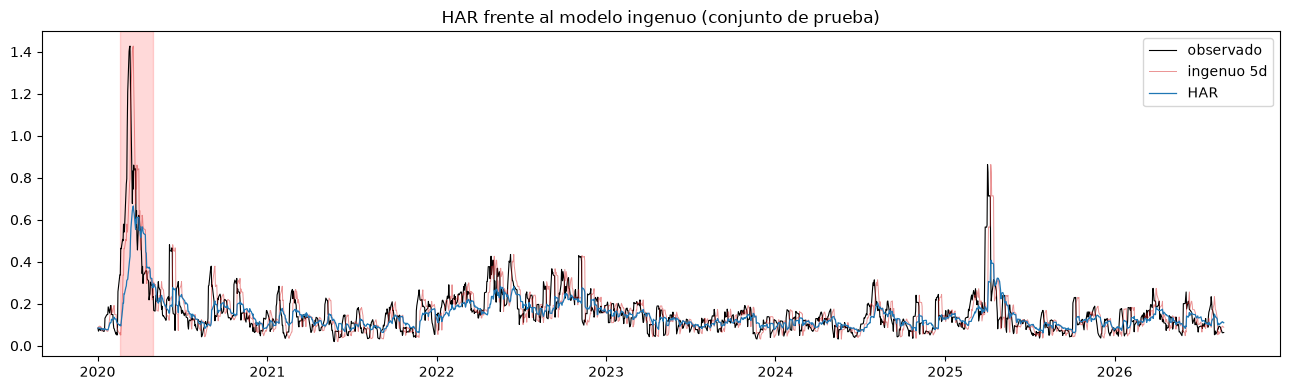

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, y_test, lw=0.8, color="black", label="observado")
ax.plot(test.index, predecir_ingenuo(test, "rv_5"), lw=0.7,
        color="tab:red", alpha=0.5, label="ingenuo 5d")
ax.plot(test.index, y_hat_har, lw=0.9, color="tab:blue", label="HAR")
ax.axvspan(idx_estres.min(), idx_estres.max(), color="red", alpha=0.15)
ax.set_title("HAR frente al modelo ingenuo (conjunto de prueba)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/e3_har.png", dpi=150)
plt.show()

In [15]:
resid = har.resid
print(f"Media de los residuos: {resid.mean():.2e}   (MCO la fuerza a 0)")
print(f"Autocorrelación en el retardo 1: {resid.autocorr(1):.3f}")
print(f"Autocorrelación en el retardo 5: {resid.autocorr(5):.3f}")

Media de los residuos: 1.58e-15   (MCO la fuerza a 0)
Autocorrelación en el retardo 1: 0.763
Autocorrelación en el retardo 5: -0.029
